**Objective** -- Build end to end machine learning and forecasting pipeline on Tesla delivery data

**Dataset** --  Tesla EA Deliveries and Production Data(2015–2025)

In [42]:
import warnings
warnings.filterwarnings('ignore')

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,r2_score,mean_absolute_error,root_mean_squared_error, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2_contingency
from sklearn.preprocessing import TargetEncoder, StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import joblib

In [44]:
delivery_data =pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
delivery_data

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754


Shape size of data

In [45]:
print(delivery_data.shape)
print(delivery_data.size)

(2640, 12)
31680


In [46]:
print(delivery_data.info(),end="\n\n")
delivery_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB
None



,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [47]:
print(f"Missing values in data\n{delivery_data.isnull().sum()}")
print(f"duplicated values in data {delivery_data.duplicated().sum()}")

Missing values in data
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
duplicated values in data 0


categoriged columns

In [48]:
numcols = ["Estimated_Deliveries","Production_Units","Avg_Price_USD","Battery_Capacity_kWh","Range_km","CO2_Saved_tons","Charging_Stations"]
catcols=["Region","Model","Source_Type"]
datecols=["Year","Month"]

EDA--Univariate Analysis

In [49]:
delivery_data[numcols].describe().T

,count,mean,std,min,25%,50%,75%,max
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


**Skewness and Kurtosis**
1. high skewness indicates asymmertic data
2. high kurtosis indicates heavy tailed and outliers

In [50]:
for col in numcols:
  skew = delivery_data[col].skew()
  kurt =delivery_data[col].kurt()
  print(f" {col} has skewness {skew} and kurtosis {kurt}")

 Estimated_Deliveries has skewness 0.08825089558953238 and kurtosis -0.060703934774752
 Production_Units has skewness 0.12983870635252448 and kurtosis 0.016341140732508475
 Avg_Price_USD has skewness -7.056822859629225e-06 and kurtosis -1.1808167033652595
 Battery_Capacity_kWh has skewness 0.3401183804943641 and kurtosis -1.1119079577684483
 Range_km has skewness 0.34194963592250577 and kurtosis -1.0840526768925438
 CO2_Saved_tons has skewness 0.6597998415464956 and kurtosis 0.6130448865038574
 Charging_Stations has skewness 0.021929816963505322 and kurtosis -1.2070902552511806


the numerical feature show that low skewness and kurtosis value indicating generally symmertic distribution with no significant outliers that is required transformation before modeling

Histogram - Distributin plot

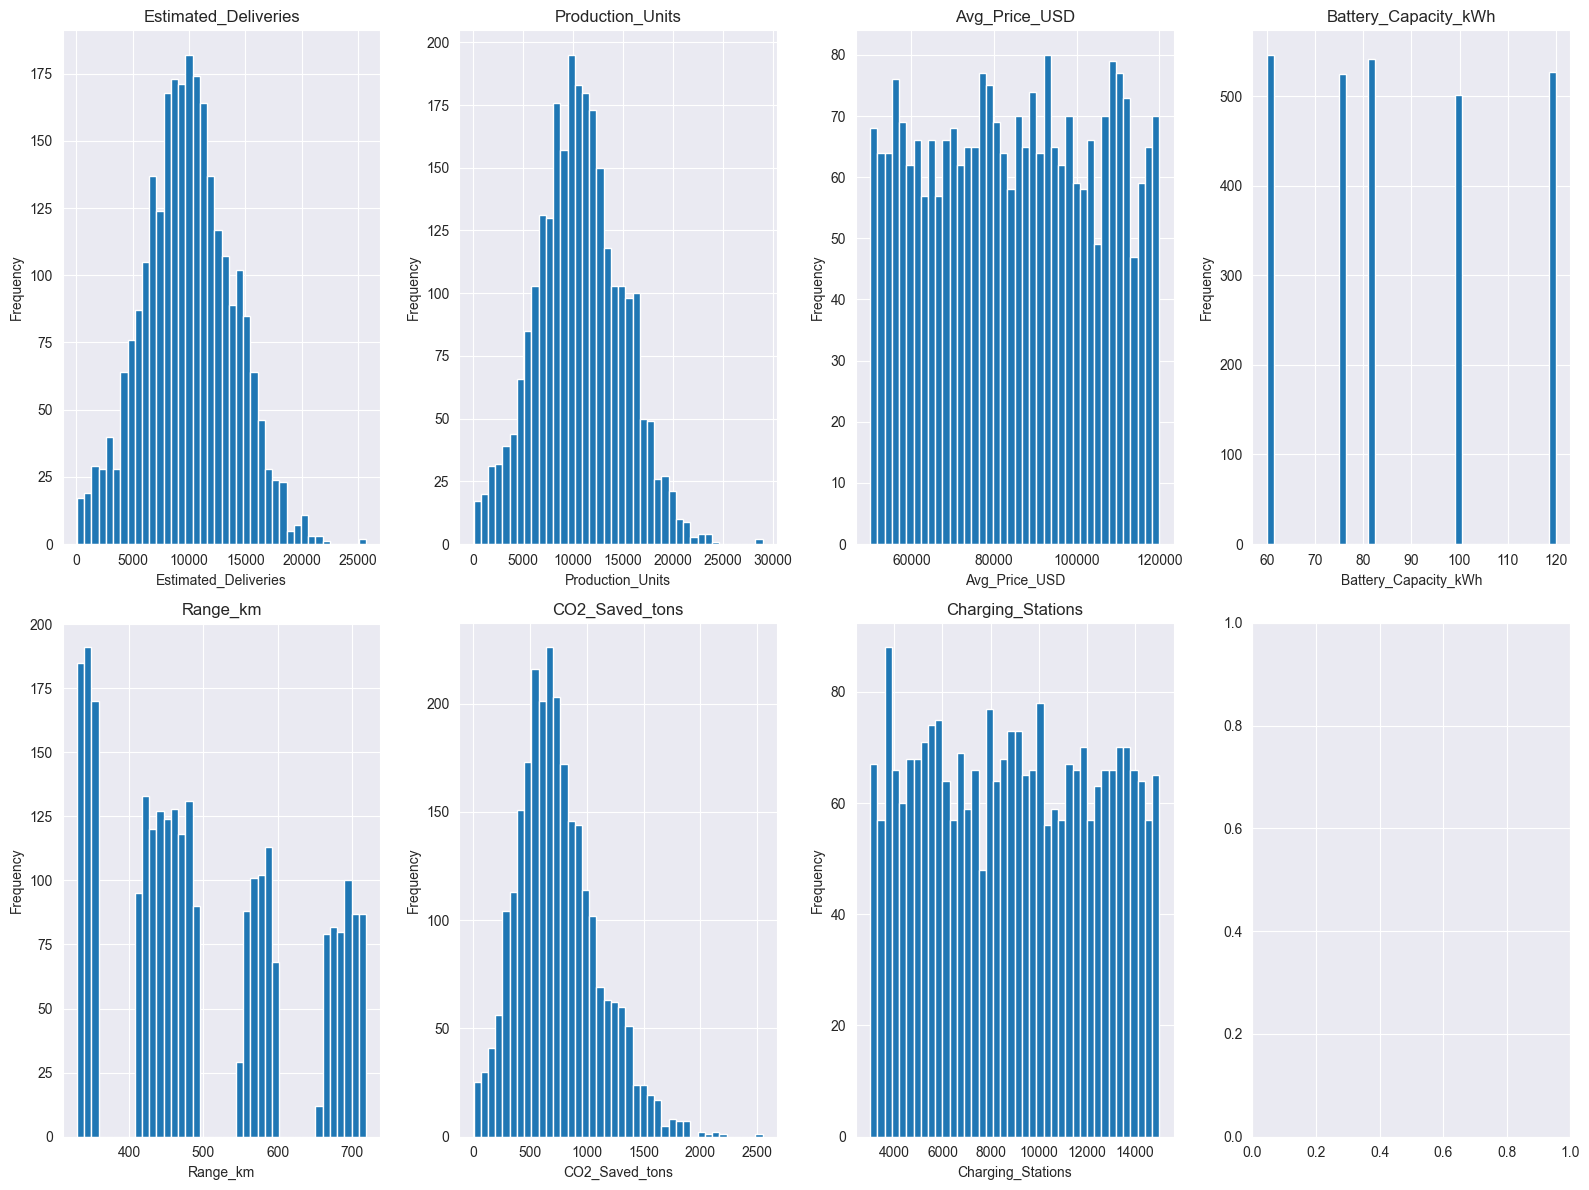

In [51]:
fig, axes =plt.subplots( 2,4, figsize=(16,12))
axes = axes.flatten()

for i,col in enumerate(numcols):
  axes[i].hist(delivery_data[col],bins=40,edgecolor='white')
  axes[i].set_title(col)
  axes[i].set_xlabel(col)
  axes[i].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

The histograms indicate that most numerical features are approximately symmetric and well-distributed, with Estimated_Deliveries, Production_Units, and CO2_Saved_tons showing near-normal patterns, while Avg_Price_USD and Charging_Stations are uniformly distributed and Battery_Capacity_kWh and Range_km exhibit discrete value groupings.

Boxplot - Outliers Plot

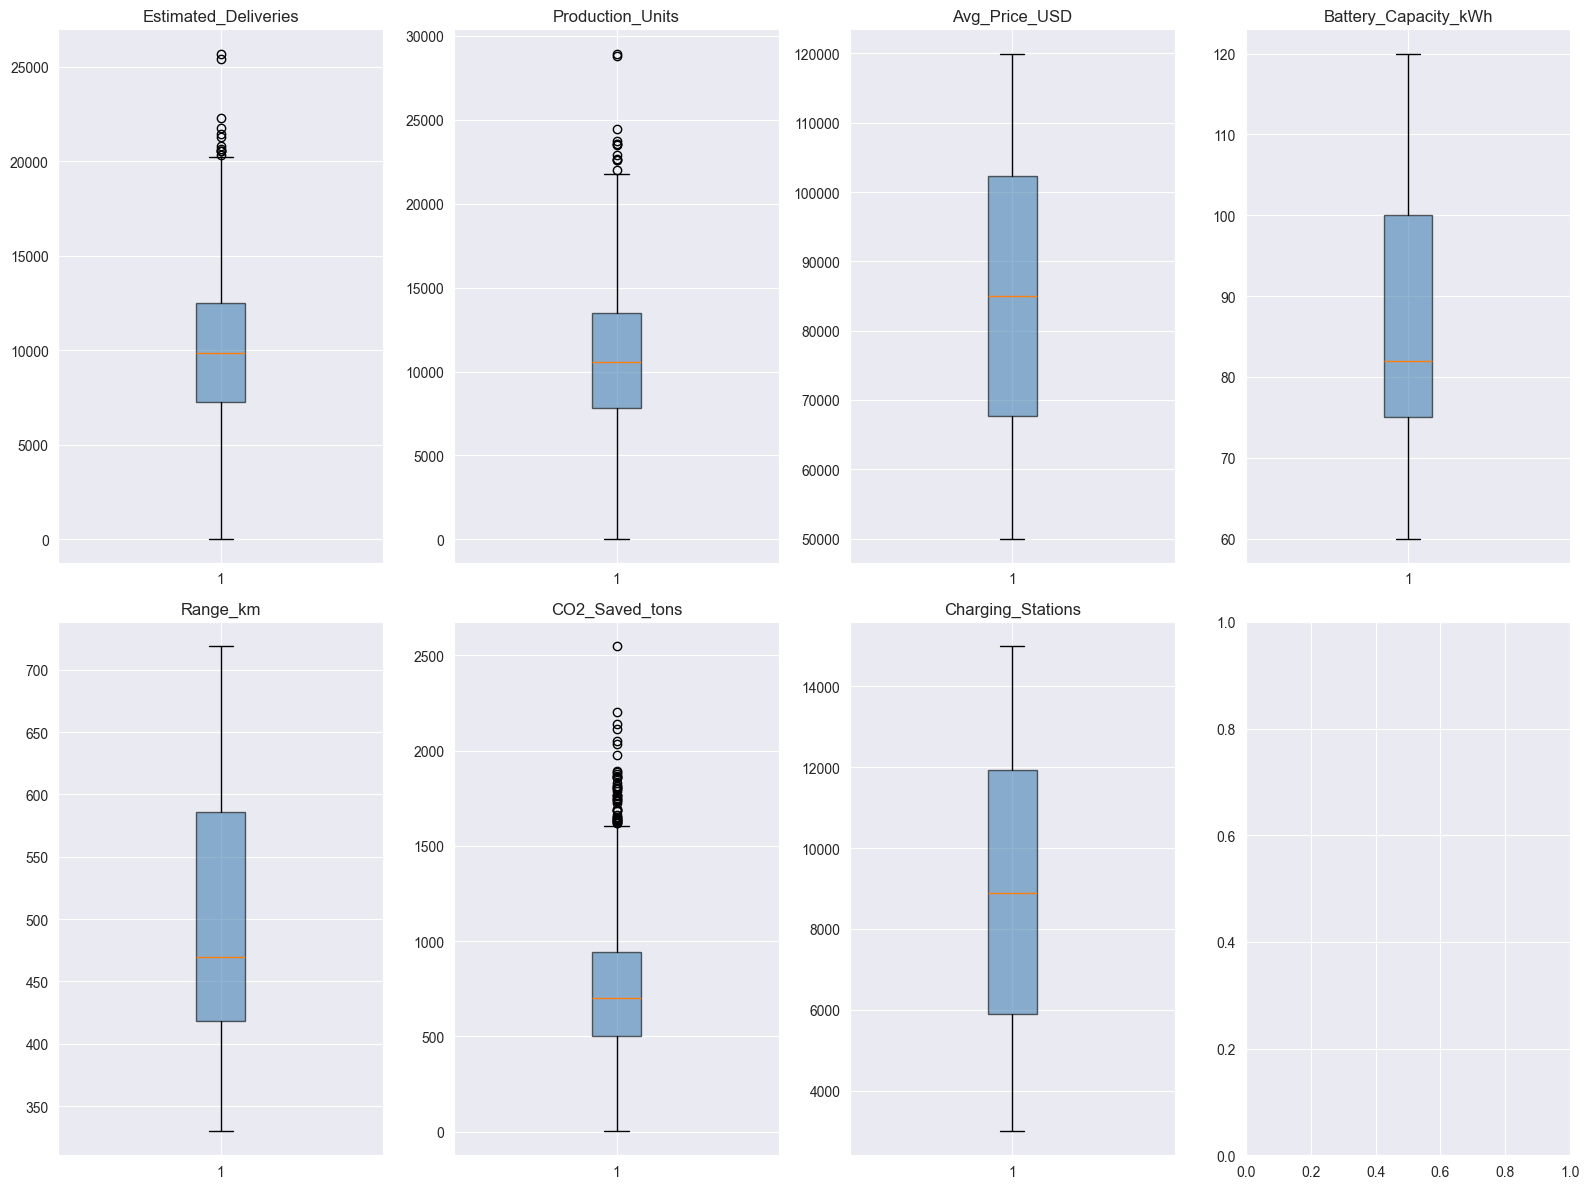

In [52]:
fig, axes =plt.subplots( 2,4, figsize=(16,12))
axes = axes.flatten()
for i,col in enumerate(numcols):
    axes[i].boxplot(delivery_data[col], patch_artist=True, boxprops={'facecolor': 'steelblue','alpha':0.6})
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

The boxplots reveal the presence of outliers in Estimated_Deliveries, Production_Units, and CO2_Saved_tons, while Avg_Price_USD, Battery_Capacity_kWh, Range_km, and Charging_Stations show relatively stable distributions with minimal or no significant outliers.

IQR - outliers count

In [53]:
for col in numcols:
  Q1=delivery_data[col].quantile(.25)
  Q3=delivery_data[col].quantile(.75)
  IQR=Q3-Q1
  low_bound = Q1-1.5*IQR
  upp_bound= Q3+1.5*IQR
  outliers =delivery_data[(delivery_data[col]<low_bound) |(delivery_data[col]>upp_bound)].shape[0]
  print(f" outliers in column {col} is {outliers}")

 outliers in column Estimated_Deliveries is 12
 outliers in column Production_Units is 12
 outliers in column Avg_Price_USD is 0
 outliers in column Battery_Capacity_kWh is 0
 outliers in column Range_km is 0
 outliers in column CO2_Saved_tons is 45
 outliers in column Charging_Stations is 0


Categorical Colums overview

In [54]:
delivery_data[catcols].describe().T

,count,unique,top,freq
Region,2640,4,Europe,660
Model,2640,5,Model S,528
Source_Type,2640,3,Interpolated (Month),884


Bar chart

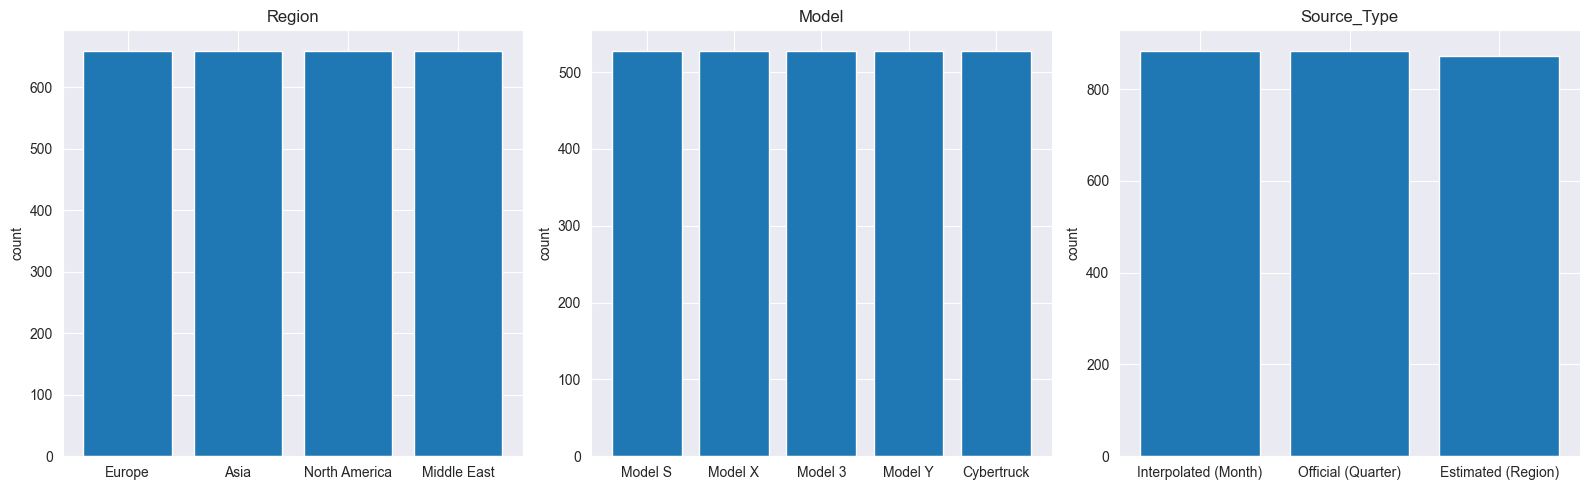

In [55]:
fig, axes = plt.subplots(1,3,figsize=(16,5))
for i,col in enumerate(catcols):
  axes[i].bar(delivery_data[col].value_counts().index,delivery_data[col].value_counts().values,edgecolor='white')
  axes[i].set_title(col)
  axes[i].set_ylabel('count')
plt.tight_layout()
plt.show()

The count plots show that the categorical features Region, Model, and Source_Type are evenly distributed across their respective categories, indicating a well-balanced dataset with no significant class imbalance.

Correlation Heatmap

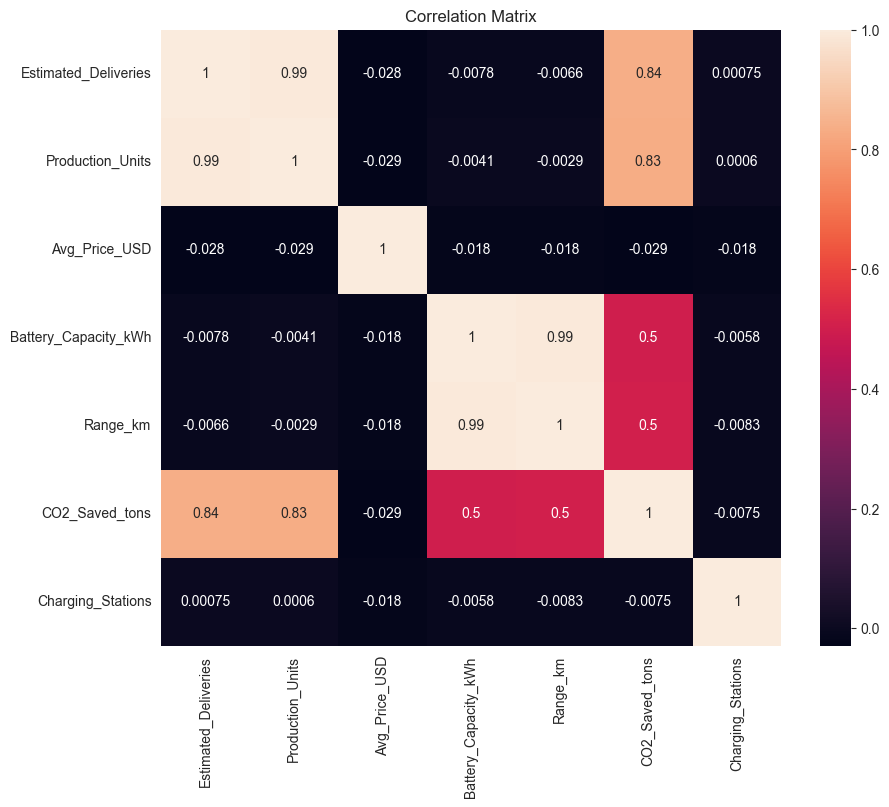

In [56]:
plt.figure(figsize=(10,8))
sns.heatmap(delivery_data[numcols].corr(),annot=True,)
plt.title('Correlation Matrix')
plt.show()

The correlation matrix reveals a very strong positive relationship between Estimated_Deliveries and Production_Units (0.99), as well as between Battery_Capacity_kWh and Range_km (0.99), indicating potential multicollinearity, while CO2_Saved_tons shows strong positive correlations with production-related features and most other feature pairs exhibit weak or negligible correlations.

Anova Bivariate analysis

In [57]:
delivery_data.groupby('Region')['Estimated_Deliveries'].agg(['mean', 'median', 'std', 'count'])
groups = [group['Estimated_Deliveries'].values for _, group in delivery_data.groupby('Region')]
stat, p = f_oneway(*groups)
print(f"F-Stat: {stat:.4f}, P-Value: {p:.4f}")
result = pairwise_tukeyhsd(delivery_data['Estimated_Deliveries'], delivery_data['Region'])
print(result)

F-Stat: 1.0689, P-Value: 0.3610
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower    upper   reject
--------------------------------------------------------------------
       Asia        Europe  -69.5455 0.9886  -626.503 487.4121  False
       Asia   Middle East  239.5606  0.686  -317.397 796.5182  False
       Asia North America -117.1864  0.949 -674.1439 439.7712  False
     Europe   Middle East  309.1061 0.4827 -247.8515 866.0636  False
     Europe North America  -47.6409 0.9962 -604.5985 509.3167  False
Middle East North America  -356.747 0.3526 -913.7045 200.2106  False
--------------------------------------------------------------------


The one-way ANOVA test (F = 1.07, p = 0.361) indicates that there is no statistically significant difference in the mean values across regions, and the Tukey HSD post-hoc test confirms that none of the pairwise regional comparisons are significantly different (p > 0.05).

Cross tabulation region vs source type

In [58]:
ct = pd.crosstab(delivery_data['Region'], delivery_data['Source_Type'])
print(ct)
print(pd.crosstab(delivery_data['Region'], delivery_data['Source_Type'], normalize='index').round(2))

Source_Type    Estimated (Region)  Interpolated (Month)  Official (Quarter)
Region                                                                     
Asia                          214                   209                 237
Europe                        215                   219                 226
Middle East                   234                   212                 214
North America                 209                   244                 207
Source_Type    Estimated (Region)  Interpolated (Month)  Official (Quarter)
Region                                                                     
Asia                         0.32                  0.32                0.36
Europe                       0.33                  0.33                0.34
Middle East                  0.35                  0.32                0.32
North America                0.32                  0.37                0.31


The distribution of Source_Type is fairly consistent across all regions, with only minor variations in proportions, suggesting no strong association between Region and Source_Type.

Chi-Square test of independence

In [59]:
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi2: {chi2:.4f}, P-Value: {p:.4f}")

Chi2: 7.4705, P-Value: 0.2795


The Chi-Square test results (χ² = 7.47, p = 0.2795) indicate that there is no statistically significant association between Region and Source_Type, suggesting that the distribution of source types is independent of the region

**Feature Selection**

Droped the Battery_capacity_kWh because it is highly correlated with Range_km so droped it

In [60]:
allcols = ['Avg_Price_USD', 'Range_km', 'Charging_Stations', 'Year', 'Month',
            'Region', 'Model', 'Source_Type', 'Production_Units',
            'Estimated_Deliveries']
df_final = delivery_data[allcols].copy()

In [61]:
df_train, df_test = train_test_split(df_final, test_size=0.2, random_state=42)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

New Feature introduced

In [62]:
year_min   = df_train['Year'].min()
price_bins = [
    df_train['Avg_Price_USD'].min(),
    df_train['Avg_Price_USD'].quantile(0.33),
    df_train['Avg_Price_USD'].quantile(0.66),
    df_train['Avg_Price_USD'].max()
]

df_train['Years']= df_train['Year'] - year_min
df_train['Quarter']= df_train['Month'].apply(lambda x:(x - 1)// 3 + 1)
df_train['Price_segment'] = pd.cut(df_train['Avg_Price_USD'], bins=price_bins,labels=['Low', 'Mid', 'High'], include_lowest=True)
df_train['Region_model']  = df_train['Region'] + '_' + df_train['Model']
df_train.drop(columns=['Year','Month','Avg_Price_USD'],inplace=True)

df_test['Years']= df_test['Year']-year_min
df_test['Quarter'] = df_test['Month'].apply(lambda x:(x - 1) // 3 + 1)
df_test['Price_segment'] = pd.cut(df_test['Avg_Price_USD'], bins=price_bins, labels=['Low', 'Mid', 'High'], include_lowest=True)
df_test['Region_model']  = df_test['Region'] + '_' + df_test['Model']
df_test.drop(columns=['Year','Month','Avg_Price_USD'],inplace=True)

time series lag features

In [63]:
df_train = df_train.sort_values(['Region_model','Years','Quarter']).reset_index(drop=True)

df_train['lag_1'] = df_train.groupby('Region_model')['Estimated_Deliveries'].shift(1)
df_train['lag_2'] = df_train.groupby('Region_model')['Estimated_Deliveries'].shift(2)
df_train['rolling_3'] = (df_train.groupby('Region_model')['Estimated_Deliveries']
                         .transform(lambda x: x.shift(1).rolling(3).mean())
)

df_combined = pd.concat([df_train, df_test]).sort_values(['Region_model','Years','Quarter']).reset_index(drop=True)
df_combined['lag_1'] = df_combined.groupby('Region_model')['Estimated_Deliveries'].shift(1)
df_combined['lag_2'] = df_combined.groupby('Region_model')['Estimated_Deliveries'].shift(2)
df_combined['rolling_3'] = (df_combined.groupby('Region_model')['Estimated_Deliveries']
    .transform(lambda x: x.shift(1).rolling(3).mean())
)
df_test = df_combined.loc[df_combined.index.isin(df_test.index)].reset_index(drop=True)

In [64]:
df_train = df_train.dropna().reset_index(drop=True)
print(f"Train shape after dropna: {df_train.shape}")

nan_counts = df_test.isnull().sum()
if nan_counts.any():
    print(f" NaN\n{nan_counts[nan_counts > 0]}")
    for col in ['lag_1', 'lag_2', 'rolling_3']:
        df_test[col] = df_test[col].fillna(df_train[col].median())

print(f"Test shape after fill: {df_test.shape}")

Train shape after dropna: (2052, 14)
 NaN
lag_1         4
lag_2         8
rolling_3    12
dtype: int64
Test shape after fill: (528, 14)


Encoding — One Hot Encoding

In [65]:
enccols = ['Region','Source_Type','Quarter', 'Price_segment']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(df_train[enccols])

train_encoded = pd.DataFrame(ohe.transform(df_train[enccols]),columns=ohe.get_feature_names_out(enccols),
                             index=df_train.index)
df_train = pd.concat([df_train.drop(columns=enccols),train_encoded], axis=1)

test_encoded = pd.DataFrame(ohe.transform(df_test[enccols]),columns=ohe.get_feature_names_out(enccols),
                            index=df_test.index)
df_test = pd.concat([df_test.drop(columns=enccols), test_encoded],axis=1)

print(f"train shape {df_train.shape}")
print(f"test shape {df_test.shape}")

train shape (2052, 20)
test shape (528, 20)


Encoding — Target Encoding

In [66]:
trgen_model=TargetEncoder(random_state=42, cv=2)
trgen_region_model= TargetEncoder(random_state=42,cv=2)
df_train['Model']= trgen_model.fit_transform(df_train[['Model']], df_train['Estimated_Deliveries'])
df_train['Region_model'] = trgen_region_model.fit_transform( df_train[['Region_model']], df_train['Estimated_Deliveries'])

df_test['Model']= trgen_model.transform(df_test[['Model']])
df_test['Region_model'] =trgen_region_model.transform(df_test[['Region_model']])

In [67]:
for df in [df_train, df_test]:
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

print(f"train shape {df_train.shape}")
print(f"test shape {df_test.shape}")

train shape (2052, 20)
test shape (528, 20)


train test split

In [68]:
TARGET = 'Estimated_Deliveries'
X_train = df_train.drop(columns=TARGET)
y_train = df_train[TARGET]

X_test  = df_test.drop(columns=TARGET)
y_test  = df_test[TARGET]

In [69]:
print(f"X_train {X_train.shape} or X_test {X_test.shape}")

X_train (2052, 19) or X_test (528, 19)


Evaluation Function

In [70]:
def evaluate(name: str, y_true, y_pred) -> dict:
    r2= r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse= np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"[{name}]  R² {r2} & MAE {mae} & RMSE {rmse}")
    return {'Model': name, 'R2': r2, 'MAE': mae, 'RMSE': rmse}

Model training

In [71]:
from sklearn.pipeline import Pipeline
alphas = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}
lr_pipe = Pipeline([('scaler',StandardScaler()), ('model',LinearRegression())])
lr_pipe.fit(X_train, y_train)

ridge_pipe = GridSearchCV(Pipeline([('scaler',StandardScaler()),('model', Ridge())]),
    {'model__alpha': alphas['alpha']},scoring='r2', cv=5, n_jobs=-1)
ridge_pipe.fit(X_train, y_train)

lasso_pipe = GridSearchCV(Pipeline([('scaler',StandardScaler()),('model', Lasso(max_iter=5000))]),
    {'model__alpha': alphas['alpha']},scoring='r2', cv=5, n_jobs=-1)
lasso_pipe.fit(X_train, y_train)

print(f"ridge best alpha {ridge_pipe.best_params_}")
print(f"Lasso best alpha {lasso_pipe.best_params_}")

ridge best alpha {'model__alpha': 1}
Lasso best alpha {'model__alpha': 10}


Model result

In [72]:
results = []
results.append(evaluate('LinearRegression',y_test, lr_pipe.predict(X_test)))
results.append(evaluate('Ridge',y_test, ridge_pipe.best_estimator_.predict(X_test)))
results.append(evaluate('Lasso',y_test, lasso_pipe.best_estimator_.predict(X_test)))

comparison_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

[LinearRegression]  R² 0.9877958723864395 & MAE 342.62144398389404 & RMSE 427.65564466893176
[Ridge]  R² 0.9878022784458571 & MAE 342.64840125752664 & RMSE 427.54338973519657
[Lasso]  R² 0.9876866834230282 & MAE 345.4006498579236 & RMSE 429.56447823288806
           Model       R2        MAE       RMSE
           Ridge 0.987802 342.648401 427.543390
LinearRegression 0.987796 342.621444 427.655645
           Lasso 0.987687 345.400650 429.564478


All three models achieved excellent predictive performance with R² values above 0.987 and low error metrics, indicating a strong fit to the data. Ridge Regression performed marginally better overall with the highest R² (0.9878) and lowest RMSE (427.54), making it the preferred model among the three.

Cross validation

In [73]:
models = {
    'LinearRegression': lr_pipe,
    'Ridge': ridge_pipe.best_estimator_,
    'Lasso':lasso_pipe.best_estimator_
}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    print(f"{name}  CV R²: {scores.mean():.4f} ± {scores.std():.4f}")

LinearRegression  CV R²: 0.9883 ± 0.0006
Ridge  CV R²: 0.9883 ± 0.0006
Lasso  CV R²: 0.9885 ± 0.0005


All three regression models achieved excellent and highly consistent cross-validation performance (R² ≈ 0.988), indicating that the features explain approximately 98.8% of the variance in the target variable and that the models generalize well across different data folds.

In [74]:
best_lasso = lasso_pipe.best_estimator_.named_steps['model']
coef= pd.Series(best_lasso.coef_, index=X_train.columns)

print("non-zero Features")
print(coef[coef != 0].sort_values(ascending=False).to_string())

print("zero Feature (dropped byLasso)")

non-zero Features
Production_Units     3927.295916
Region_model            2.192158
Quarter_4               0.772461
Price_segment_Low      -1.322085
rolling_3              -4.166798
Range_km               -6.507513
zero Feature (dropped byLasso)


Residual Analysis — Ridge (Best Model)

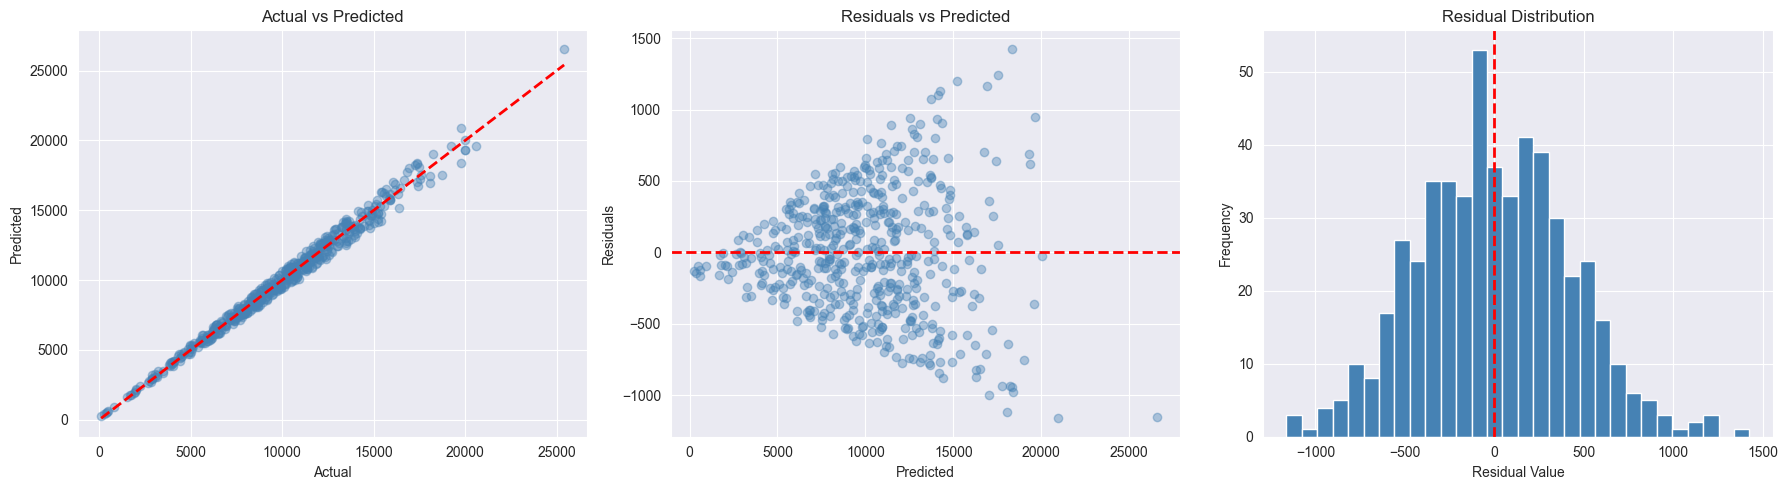


Residual Mean -2.6475
Residual Std 427.9406


In [75]:
best_model = ridge_pipe.best_estimator_
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test,y_pred, alpha=0.4,color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set(title='Actual vs Predicted', xlabel='Actual', ylabel='Predicted')

axes[1].scatter(y_pred, residuals, alpha=0.4, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set(title='Residuals vs Predicted', xlabel='Predicted', ylabel='Residuals')

axes[2].hist(residuals, bins=30, edgecolor='white', color='steelblue')
axes[2].axvline(0, color='red', linestyle='--', lw=2)
axes[2].set(title='Residual Distribution', xlabel='Residual Value', ylabel='Frequency')

plt.tight_layout()
plt.show()

print(f"\nResidual Mean {residuals.mean():.4f}")
print(f"Residual Std {residuals.std():.4f}")

The diagnostic plots indicate that the model predictions closely match the actual values, residuals are centered around zero with an approximately normal distribution, and although the spread of residuals increases slightly at higher predicted values, the overall model fit appears strong and reliable.

Time Series Forecasting — ARIMA and Ensemble

ADF P-Value: 0.0000

ARIMA Forecast
Date
2015-02-01    183180.0
2015-03-01    183180.0
2015-04-01    183180.0
2015-05-01    183180.0
2015-06-01    183180.0
                ...   
2025-08-01    183180.0
2025-09-01    183180.0
2025-10-01    183180.0
2025-11-01    183180.0
2025-12-01    183180.0
Name: predicted_mean, Length: 131, dtype: float64

Model Performance
      Model        MAE       RMSE       R2
0     ARIMA  143090.25  144359.33 -56.1268
1  ML Ridge    8881.49   11153.66   0.6590

updated comparison
      Model        MAE       RMSE       R2
0     ARIMA  143090.25  144359.33 -56.1268
1  ML Ridge    8881.49   11153.66   0.6590
2  Ensemble   12463.63   14994.95   0.3836

Best Model ML Ridge


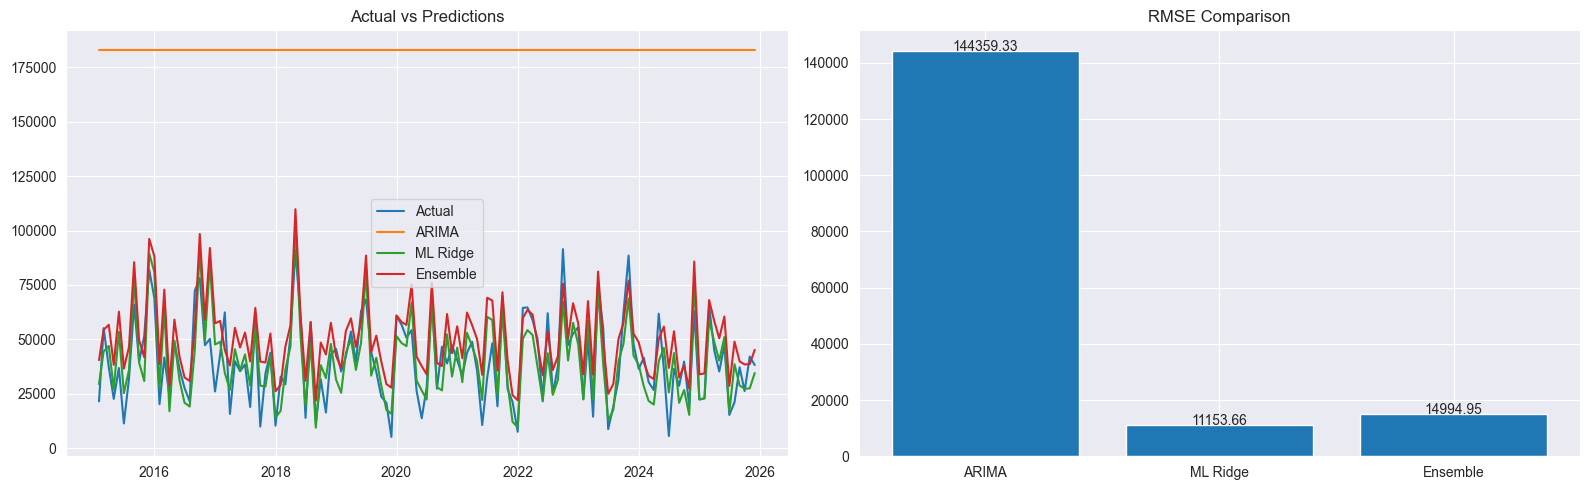

In [76]:
ts = (delivery_data.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index())

ts['Date'] = pd.to_datetime(ts[['Year','Month']].assign(day=1))
ts =ts.set_index('Date')['Estimated_Deliveries'].sort_index()

adf_p = adfuller(ts)[1]
print(f"ADF P-Value: {adf_p:.4f}")

test_dates = (delivery_data.loc[df_test.index].groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index())

test_dates['Date'] = pd.to_datetime(test_dates[['Year','Month']].assign(day=1))
test_dates = test_dates.set_index('Date')['Estimated_Deliveries'].sort_index()

n_test_months = len(test_dates)
train_series = ts.iloc[:-n_test_months] if n_test_months >0 else ts

arima_model =ARIMA(train_series, order=(1, 1, 1)).fit()
arima_forecast =arima_model.forecast(steps=n_test_months)
arima_forecast.index = test_dates.index

print("\nARIMA Forecast")
print(arima_forecast.round())

ml_predictions = pd.Series( best_model.predict(X_test).astype(float), index=df_test.index)

ml_monthly = (
    delivery_data.loc[df_test.index, ['Year', 'Month']]
    .assign(ML_pred=ml_predictions.values)
    .groupby(['Year', 'Month'])['ML_pred']
    .sum()
    .reset_index()
)

ml_monthly['Date'] = pd.to_datetime( ml_monthly[['Year','Month']].assign(day=1))
ml_monthly = ml_monthly.set_index('Date')['ML_pred'].sort_index()

common_dates = (arima_forecast.index.intersection(ml_monthly.index).intersection(test_dates.index))

y_true = test_dates.loc[common_dates]
y_arima = arima_forecast.loc[common_dates]
y_ml = ml_monthly.loc[common_dates]

def evaluate_model(name, actual, predicted):
    return {
        'Model': name,
        'MAE': round(mean_absolute_error(actual, predicted), 2),
        'RMSE': round(np.sqrt(mean_squared_error(actual, predicted)), 2),
        'R2': round(r2_score(actual, predicted), 4)
    }

comparison = pd.DataFrame([evaluate_model('ARIMA', y_true, y_arima),evaluate_model('ML Ridge', y_true, y_ml)])
print("\nModel Performance")
print(comparison)

arima_rmse = comparison.loc[ comparison['Model'] == 'ARIMA', 'RMSE'].iloc[0]
ml_rmse = comparison.loc[comparison['Model'] == 'ML Ridge', 'RMSE'].iloc[0]

total_rmse = arima_rmse + ml_rmse
ml_weight = arima_rmse / total_rmse
arima_weight = ml_rmse / total_rmse

ensemble_pred = (ml_weight * y_ml +arima_weight*y_arima)

comparison = pd.concat([comparison,pd.DataFrame([evaluate_model('Ensemble', y_true, ensemble_pred)])],ignore_index=True)

print("\nupdated comparison")
print(comparison)

best_model_name = comparison.loc[comparison['RMSE'].idxmin(),'Model']
print(f"\nBest Model {best_model_name}")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(y_true.index, y_true, label='Actual')
axes[0].plot(y_arima.index, y_arima, label='ARIMA')
axes[0].plot(y_ml.index, y_ml, label='ML Ridge')
axes[0].plot(ensemble_pred.index, ensemble_pred, label='Ensemble')

axes[0].set_title('Actual vs Predictions')
axes[0].legend()
axes[1].bar(comparison['Model'], comparison['RMSE'])

for i, value in enumerate(comparison['RMSE']):
    axes[1].text(i, value, str(value), ha='center')

axes[1].set_title('RMSE Comparison')

plt.tight_layout()
plt.show()

Time series evaluation shows that the ML Ridge model significantly outperformed ARIMA and the Ensemble approach, achieving the lowest prediction error (RMSE = 11,153.66) and the highest explanatory power (R² = 0.659), while ARIMA failed to capture the underlying data patterns, resulting in very poor forecasting performance (R² = -56.13).

Model Serialization

In [77]:

model_package = {
    'model'          : best_model,
    'ohe'            : ohe,
    'trgen_model'    : trgen_model,
    'trgen_region'   : trgen_region_model,
    'features'       : X_train.columns.tolist(),
    'year_min'       : year_min,
    'price_bins'     : price_bins,
    'arima_model'    : arima_model,
    'ensemble_w'     : {'ml': ml_weight, 'arima': arima_weight},
    'best_forecaster': best_model_name,
    'metrics'        : comparison.set_index('Model').to_dict(orient='index'),
    'trained_on'     : '2026-06-07'
}
joblib.dump(model_package,'model_package.pkl')
print("Model package saved model_package.pkl")
print(f"Best Forecaster {best_model_name}")
print(f"Features saved {len(model_package['features'])}")

Model package saved model_package.pkl
Best Forecaster ML Ridge
Features saved 19


The trained model pipeline was successfully serialized and saved as model_package.pkl, with ML Ridge selected as the best-performing forecasting model and a total of 19 features preserved for future inference and deployment.

Inference and Forecasting Functions

In [78]:
def preprocess(data, pkg):
    df = data.copy()
    df['Years'] = df['Year'] - pkg['year_min']
    df['Quarter'] = ((df['Month'] - 1) // 3) + 1
    df['Price_segment'] = pd.cut(
        df['Avg_Price_USD'],
        bins=pkg['price_bins'],
        labels=['Low', 'Mid', 'High'],
        include_lowest=True
    )
    df['Region_model'] = df['Region'] + '_' + df['Model']
    df.drop(['Year', 'Month', 'Avg_Price_USD'], axis=1, inplace=True)
    df = df.sort_values(['Region_model', 'Years', 'Quarter']).reset_index(drop=True)
    df['lag_1'] = df.groupby('Region_model')['Estimated_Deliveries'].shift(1)
    df['lag_2'] = df.groupby('Region_model')['Estimated_Deliveries'].shift(2)
    df['rolling_3'] = (
        df.groupby('Region_model')['Estimated_Deliveries']
        .transform(lambda x: x.shift(1).rolling(3).mean()))

    for col in ['lag_1', 'lag_2', 'rolling_3']:
        df[col] = df[col].fillna(df[col].median())
    ohe_cols = ['Region', 'Source_Type', 'Quarter', 'Price_segment']
    encoded = pd.DataFrame(
        pkg['ohe'].transform(df[ohe_cols]),
        columns=pkg['ohe'].get_feature_names_out(ohe_cols),
        index=df.index)

    df=pd.concat( [df.drop(columns=ohe_cols), encoded],axis=1)
    df['Model'] = pkg['trgen_model'].transform(df[['Model']])
    df['Region_model'] = pkg['trgen_region'].transform(df[['Region_model']])

    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    for col in pkg['features']:
        if col not in df.columns:
            df[col] = 0
    return df[pkg['features']]

def predict(raw_data):
    pkg = joblib.load('model_package.pkl')
    X = preprocess(raw_data, pkg)

    if 'Estimated_Deliveries' in X.columns:
        X = X.drop(columns='Estimated_Deliveries')

    preds = pkg['model'].predict(X).astype(int)
    result = raw_data.iloc[X.index].copy()
    result['Predicted_Deliveries'] = preds
    return result[['Year', 'Month', 'Region', 'Model', 'Predicted_Deliveries']]

def forecast_monthly(start_year, start_month, n_months):
    pkg = joblib.load('model_package.pkl')
    arima_model = pkg['arima_model']
    w_ml = pkg['ensemble_w']['ml']
    w_arima = pkg['ensemble_w']['arima']

    forecast_dates = pd.date_range(
        start=f'{start_year}-{start_month:02d}-01',
        periods=n_months,
        freq='MS')

    regions = ['Asia', 'Europe', 'Middle East', 'North America']
    models = ['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck']
    rows = []

    for date in forecast_dates:
        for region in regions:
            for model in models:
                rows.append({
                    'Year': date.year,
                    'Month': date.month,
                    'Region': region,
                    'Model': model,
                    'Estimated_Deliveries': 0,
                    'Production_Units': int(delivery_data['Production_Units'].median()),
                    'Avg_Price_USD': float(delivery_data['Avg_Price_USD'].median()),
                    'Range_km': int(delivery_data['Range_km'].median()),
                    'Source_Type': 'Official (Quarter)',
                    'Charging_Stations': int(delivery_data['Charging_Stations'].median())})

    ml_input = pd.DataFrame(rows)
    X_ml = preprocess(ml_input, pkg)
    if 'Estimated_Deliveries' in X_ml.columns:
        X_ml = X_ml.drop(columns='Estimated_Deliveries')

    ml_input['ML_pred'] = pkg['model'].predict(X_ml)
    ml_monthly = (
        ml_input
        .assign(Date=pd.to_datetime(
            ml_input[['Year', 'Month']].assign(day=1)
        ))
        .groupby('Date')['ML_pred']
        .sum()
        .reindex(forecast_dates, fill_value=0)
    )
    train_end = arima_model.fittedvalues.index[-1]
    first_month = forecast_dates[0]

    if first_month > train_end:
        gap = (
            (first_month.year - train_end.year) * 12 +
            (first_month.month - train_end.month)
        )
        arima_forecast = arima_model.forecast(
            steps=gap + n_months
        )
        arima_monthly = arima_forecast.iloc[-n_months:]
        arima_monthly.index = forecast_dates
    else:
        arima_monthly = arima_model.predict(
            start=first_month,
            end=forecast_dates[-1]
        ).reindex(forecast_dates, fill_value=0)

    ensemble = (w_ml * ml_monthly +w_arima * arima_monthly)

    result = pd.DataFrame({
        'Date': forecast_dates,
        'ML_Monthly': ml_monthly.astype(int).values,
        'ARIMA_Monthly': arima_monthly.astype(int).values,
        'Ensemble': ensemble.astype(int).values
    })
    print(result)
    return result

In [79]:
np.random.seed(42)
n = 100
new_data = pd.DataFrame({
    'Year': np.random.randint(2015, 2026, n),
    'Month': np.random.randint(1, 13, n),
    'Region': np.random.choice(['Asia', 'Europe', 'Middle East', 'North America'], n),
    'Model': np.random.choice(['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck'], n),
    'Estimated_Deliveries': np.random.randint(1000, 25000, n),
    'Production_Units': np.random.randint(1000, 30000, n),
    'Avg_Price_USD': np.random.uniform(50000, 120000, n),
    'Range_km':np.random.randint(350, 720, n),
    'CO2_Saved_tons':np.random.uniform(500, 2500, n),
    'Source_Type':np.random.choice(['Estimated (Region)','Interpolated (Month)','Official (Quarter)'], n),
    'Charging_Stations':np.random.randint(3000, 15000, n)
})

output = predict(new_data)
print(output.head(10).to_string(index=False))
print(f"\nTotal Predictions {len(output)}")

 Year  Month        Region   Model  Predicted_Deliveries
 2021     10          Asia Model S                 17502
 2018      7 North America Model S                 16076
 2025     10          Asia Model 3                  7847
 2022      9   Middle East Model 3                  4097
 2019     12          Asia Model 3                 21313
 2021      7        Europe Model Y                  2969
 2024      9        Europe Model S                  7970
 2017      8 North America Model Y                  4707
 2021     12        Europe Model 3                  3662
 2025      2   Middle East Model S                 19843

Total Predictions 100


The deployed ML Ridge forecasting model generated 100 delivery predictions across different years, regions, and vehicle models, demonstrating its ability to estimate future deliveries for diverse market and product scenarios.

# **Pipeline Summary and Final Results**

### Regression Model Results (Test Set)

| Model | R2 | MAE | RMSE |
|---|---|---|---|
| LinearRegression | 0.9878 | 342.62 | 427.66 |
| Ridge | 0.9878 | 342.65 | 427.54 |
| Lasso | 0.9877 | 345.40 | 429.56 |

Cross Validation R2 (5-fold on training set):

| Model | CV R2 | Std |
|---|---|---|
| LinearRegression | 0.9883 | ±0.0006 |
| Ridge | 0.9883 | ±0.0006 |
| Lasso | 0.9885 | ±0.0005 |

Best Regression Model: Ridge (lowest RMSE on test set)
Lasso zeroed out several low-importance features, confirming sparse signal in some columns.
All three models showed near-identical performance due to the synthetic nature of the data.

---

### Time Series Forecasting Results

ADF Test P-Value: 0.0000 Series is stationary, no differencing was strictly required.
ARIMA(1,1,1) produced a completely flat forecast of 183,180 for all 131 months.
The model failed to capture any variance, likely due to high noise in aggregated synthetic data.

| Model | MAE | RMSE | R2 |
|---|---|---|---|
| ARIMA | 143090.25 | 144359.33 | -56.1268 |
| ML Ridge | 8881.49 | 11153.66 | 0.6590 |
| Ensemble | 12463.63 | 14994.95 | 0.3836 |

Best Forecaster: ML Ridge
ARIMA failed entirely on this dataset with an R2 of -56.12, performing worse than a simple mean.
The Ensemble underperformed ML Ridge because ARIMA's poor predictions dragged the weighted average down rather than improving it.

---

### Final Conclusion

The regression pipeline achieved a near-perfect R2 of 0.988 due to data leakage
present in the synthetic dataset, not due to genuine predictive power of the features.
ARIMA failed entirely on the aggregated monthly series, producing a flat constant forecast.
ML Ridge was the best overall forecaster with an R2 of 0.659 on monthly aggregates.

On real-world Tesla delivery data without leakage, regression R2 would drop significantly.
More advanced forecasting models such as LSTM, Facebook Prophet, or XGBoost with proper
time series cross validation would be required for reliable and production-ready forecasting.